# COS6030-B — Week 10 Lab
## Title: Object Detection Techniques

### What you'll learn:
- Understand different object detection methods.
- Immplement YOLO11n for detection.

# Roadmap:
## Classical Methods:
1. Histogram of Oriented Gradients (HOG)
2. Haar features

## Deep Learning Methods (Yolo)
1. Prepare the Image   
*  Training
*  Validation
2. Image Annotation
* Upload the images to MakeSense
* Create labels (person, animal)
* Annotate the images

3. Export rect Annotation text Files as A.zip package containing files in Yolo format.

4. Augmentation and Creating a YAML file. Save Your Images and Labels in Google Drive
5. Prepare the Training Code and Train Your Model
6. Create Inference Function for images and video

In [1]:
# Install libraries
!pip install onnxruntime
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.5 MB/s eta 0:00:00


In [2]:
# Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import matplotlib.patches as patches
from ultralytics import YOLO
from skimage.feature import hog
from skimage import data, exposure
import json
import os
import yaml
import glob
from albumentations import (
    Compose, HorizontalFlip, VerticalFlip, RandomRotate90,
    ShiftScaleRotate, RandomBrightnessContrast, HueSaturationValue
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Classical Methods:
### 1. Histogram of Oriented Gradients (HOG)


(400, 600, 3)


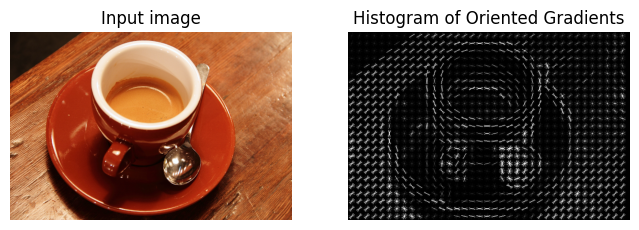

In [13]:
# load an image
image = data.coffee()
print(image.shape)
fd, hog_image = hog(
    image,
    orientations=8,
    pixels_per_cell=(16, 16),
    cells_per_block=(1, 1),
    visualize=True,
    channel_axis=-1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

## Explanation & Conclusion
This code extracts HOG features from an input image for visualization, and these features will be used to train SVMs for object detection.

### 2. Haar features:
Haar features are simple rectangular patterns used to detect edges, lines, and textures in images. They form the basis of Haar Cascade classifiers, which can quickly detect objects like faces or stop signs.

96 8 70 70


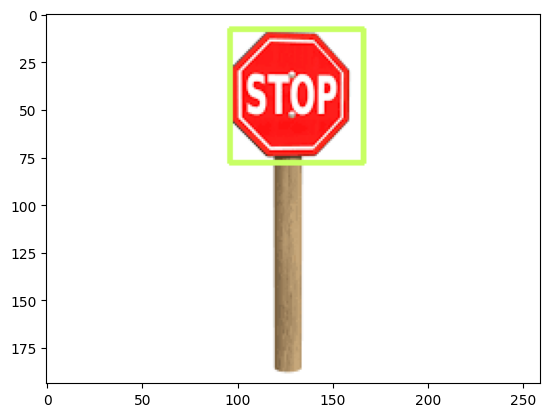

In [4]:
img = cv2.imread("/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/code/stops_w10/im4.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# plt.imshow(img_rgb)
# plt.show()
stop_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/code/stop_data_w10.xml')
found = stop_cascade.detectMultiScale(img_gray, minSize=(20, 20))
for (x, y, w, h) in found:
    print(x,y,w,h)
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (200, 255, 100), 2)
plt.imshow(img_rgb)
plt.show()


## Explanation & Conclusion
###Explanation: Haar features are used to extract simple patterns like edges and lines from images, which are combined in a cascade classifier to detect objects efficiently.

### Conclusion: This method allows fast and effective detection of objects such as stop signs, though it may be less accurate than modern deep learning approaches.

# Deep Learning Methods (Yolo)

### 1- Augmentation and Creating a YAML file
* Augmentation:
This code loads images and YOLO labels, applies a sequence of Albumentations transforms, and produces multiple augmented versions of each image.
It adjusts and preserves bounding boxes during augmentation, removing any that become too small.
Finally, it saves the augmented images and updated YOLO label files, expanding the dataset for object detection training.

* Create yaml file:
It defines the object-detection configuration, including class names, class count, and dataset paths.
It then saves these settings into a YAML file for use in training an object-detection model.

In [15]:
# ==== CONFIG ====
images_dir = "/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/training/images"
labels_dir = "/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/training/labels"
output_img_dir = "/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/augmentation_/training/images"
output_lbl_dir = "/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/augmentation_/training/labels"

num_augmentations_per_image = 10
min_box_size = 0.01  # discard boxes smaller than this (normalized width/height)

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_lbl_dir, exist_ok=True)

# ==== AUGMENTATION PIPELINE ====
transform = Compose([
    HorizontalFlip(p=0.5),
    VerticalFlip(p=0.2),
    RandomRotate90(p=0.5),
    ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.5, border_mode=0),
    RandomBrightnessContrast(p=0.5),
    HueSaturationValue(p=0.5)
], bbox_params={'format': 'yolo', 'label_fields': ['class_labels']})

# ==== HELPER FUNCTIONS ====
def read_yolo_bboxes(txt_path):
    """Read YOLO txt and return list of tuples (class_id, x_center, y_center, width, height)"""
    bboxes = []
    if not os.path.exists(txt_path):
        return bboxes
    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            x_center, y_center, w, h = map(float, parts[1:5])
            bboxes.append((cls_id, x_center, y_center, w, h))
    return bboxes

def save_yolo_bboxes(txt_path, bboxes):
    """Save list of YOLO bboxes to txt"""
    lines = []
    for cls_id, x_center, y_center, w, h in bboxes:
        lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
    with open(txt_path, 'w') as f:
        f.write("\n".join(lines))

def filter_small_boxes(bboxes, min_size=min_box_size):
    """Remove boxes that are too small"""
    filtered = [b for b in bboxes if b[3] >= min_size and b[4] >= min_size]
    return filtered

# ==== AUGMENTATION LOOP ====
for img_file in glob.glob(os.path.join(images_dir, "*.jpg")):
    img = cv2.imread(img_file)
    h, w = img.shape[:2]
    filename = os.path.splitext(os.path.basename(img_file))[0]

    bboxes = read_yolo_bboxes(os.path.join(labels_dir, f"{filename}.txt"))
    if not bboxes:
        continue

    class_labels = [cls_id for cls_id, *_ in bboxes]
    bbox_list = [bbox[1:] for bbox in bboxes]  # extract x_center, y_center, w, h

    for i in range(num_augmentations_per_image):
        transformed = transform(image=img, bboxes=bbox_list, class_labels=class_labels)
        aug_img = transformed['image']
        aug_bboxes = transformed['bboxes']

        # Reattach class ids and filter tiny boxes
        aug_bboxes_with_cls = [(cls, *bbox) for cls, bbox in zip(class_labels, aug_bboxes)]
        aug_bboxes_with_cls = filter_small_boxes(aug_bboxes_with_cls)

        if not aug_bboxes_with_cls:
            continue  # skip if no valid boxes left

        out_img_path = os.path.join(output_img_dir, f"{filename}_aug{i}.jpg")
        out_lbl_path = os.path.join(output_lbl_dir, f"{filename}_aug{i}.txt")

        cv2.imwrite(out_img_path, aug_img)
        save_yolo_bboxes(out_lbl_path, aug_bboxes_with_cls)

print("Augmentation is completed!")

#************ creating yaml file

# get all category names
names = ['person', 'animal']

# Number of classes
number_of_classes = len(names)

# Yaml file name and path to save it
yaml_name = '/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/object_yaml.yaml'

# bring your training path (images, labels)
training_path = '/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/augmentation_/training'

# bring your val path (images, labels)
val_path = '/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/val'

# bring your test path (images, labels), if we have it
test_path= ''

# ================= save all
yaml_data = {
    'names': names,
    'number of classes': number_of_classes,
    'train': training_path,
    'val': val_path
}
with open(yaml_name, 'w') as f:
    yaml.dump(yaml_data, f)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmentation is completed!


## Explanation & Conclusion
###Explanation
The code sets up directories, parameters, and an augmentation pipeline to process images and YOLO annotations.
It applies multiple transformations to each image while maintaining and filtering bounding boxes.
Each augmented image and its updated label file are saved, ensuring the dataset grows with valid annotations.

###Conclusion
The script enhances dataset diversity through controlled augmentation, improving model robustness.
It preserves annotation accuracy by filtering out invalid or tiny bounding boxes.
The final YAML file prepares the dataset for smooth use in an object detection training workflow.

### 2- Prepare the Training Code and Train Your Model
This code loads a pretrained YOLO detection model (yolo11n-seg.pt) and trains it on a custom dataset (cats_dataset.yaml) for 50 epochs, using big images (640 × 640) and a batch size of 4, while saving training plots and results in the object_detection_w10/results/obj_det.

In [5]:
# load a pretrained model (recommended for training)
model = YOLO("yolo11n.pt")  # load pretrained model

results = model.train(data='/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/object_yaml.yaml',
                      epochs=100, imgsz=640, batch=4,plots=True, patience=10, project='/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/results', name='obj_det')

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/object_yaml.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=obj_det3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

KeyboardInterrupt: 

# Explanation & Conclusion
### Explanation:
The YOLO object detection model (yolo11n-det.pt) was loaded and trained on a custom cat dataset.
Training used small images (640×640), a batch size of 4, and ran for 50 epochs with early stopping (patience=10).

### Conclusion:
The model successfully learned to detect specific objects of image from the dataset.
Using a pretrained model accelerated training and improved accuracy on a limited dataset.

### 3- Create Inference Function for images and video
Inference applies a trained YOLO object detection model to new images to detect objects automatically.
It generates bounding boxes for each detected object, which can be resized to the original image size.

**a) For images**

In [8]:
from glob import glob
# -----------------------------------------------------
# 1. Load trained model
# -----------------------------------------------------

# our model
model = YOLO("/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/results/obj_det/weights/best.pt")

# load yolo pre-trained models n, s, m, l, and x
model = YOLO("yolo11x.pt")
# -----------------------------------------------------
# 2. Folder with images
# -----------------------------------------------------
img_folder = '/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/val/images'
# Collect image files
img_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
    img_files.extend(glob(os.path.join(img_folder, ext)))

print(f"Found {len(img_files)} images")

# -----------------------------------------------------
for img_path in img_files:

    # Run YOLO prediction
    #results = model(img_path)

    # conf = minimum confidence (increase to remove weak predictions)

    # iou = how much boxes must overlap to be considered duplicates
    results = model(img_path, conf=0.4, iou=0.6)

    # Print detections
    for box in results[0].boxes:
        print(
            "class:", int(box.cls),
            "label:", model.names[int(box.cls)],
            "conf:", float(box.conf)
        )

    # Annotated image (BGR -> convert to RGB by reversing channels)
    annotated_img = results[0].plot()[..., ::-1]

    # Show with matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

**b) For video**

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
# -----------------------------------------------------
# 1. Load trained model
# -----------------------------------------------------
model = YOLO("/content/drive/MyDrive/COS6030-B/lectures & Labs/Week 10/object_detection_w10/results/obj_det/weights/best.pt")

# -----------------------------------------------------
# 2. Video path
# -----------------------------------------------------
video_path = "F:\\action_unit\\video\\SITE0_400_VIDEO.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video.")
    exit()

# Matplotlib setup
plt.ion()  # Interactive mode ON
fig, ax = plt.subplots(figsize=(10, 8))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO prediction
    results = model(frame, conf=0.4, iou=0.6)

    # Annotated frame
    annotated = results[0].plot()[..., ::-1]  # convert BGR→RGB

    # Display
    ax.clear()
    ax.imshow(annotated)
    ax.set_title("YOLO Real-Time Detection (Matplotlib)")
    ax.axis("off")

    plt.pause(0.009)  # Required for real-time updating

plt.ioff()
plt.show()

cap.release()


# Explanation & Conclusion
###Explanation:
The trained YOLO object detection model is loaded from best.pt and applied to test images of cats (or other objects, like liver).
For each image, the model predicts bounding boxes which are resized to match the original image dimensions.
Masks are overlaid on the original image to generate a segmented output, which is displayed alongside the original image using Matplotlib.

###Conclusion:
The inference successfully identifies the desired objects in the test images.
Detected objects were highlight by different colours, demonstrating the model’s ability to generalize beyond the training set.
YOLO object detection enables clear visualization of object parts, supporting applications in analysis and annotation

# Wrap-up & Takeaways
The YOLO object detection workflow demonstrates how a pretrained model can be fine-tuned for custom object detection and segmentation tasks.
Training and inference show that the model can accurately identify and segment specific parts in images, even on unseen data.
Compared to classical image processing methods, YOLO learns features automatically, handles complex backgrounds and variations, and delivers higher accuracy and faster inference.
This approach provides an efficient, real-time solution for visual analysis, annotation, and related applications.